In [20]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Add the root directory to sys.path to import src
sys.path.append(str(Path.cwd().parent))

from src.data_loader import load_market_data
from src.features import build_feature_dataset

# Load data and build features
df_raw = load_market_data()
data, predictors = build_feature_dataset(df_raw)

print(f"Data loaded successfully. Shape: {data.shape}")

Data loaded successfully. Shape: (8145, 17)


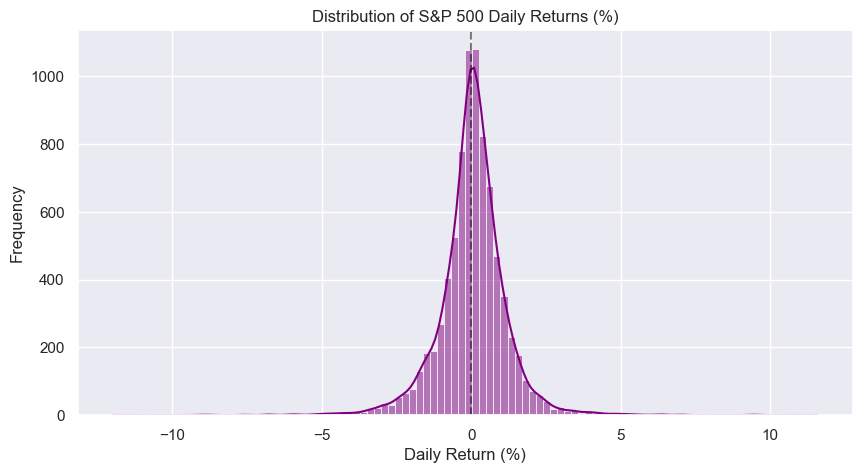

Kurtosis: 10.47 (Normal distribution is ~3.0)


In [21]:
# Calculate daily percentage change to view returns
data['Daily_Return'] = data['Close'].pct_change() * 100

plt.figure(figsize=(10, 5))
sns.histplot(data['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title("Distribution of S&P 500 Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.show()

# Check for 'Fat Tails' (Kurtosis)
print(f"Kurtosis: {data['Daily_Return'].kurtosis():.2f} (Normal distribution is ~3.0)")

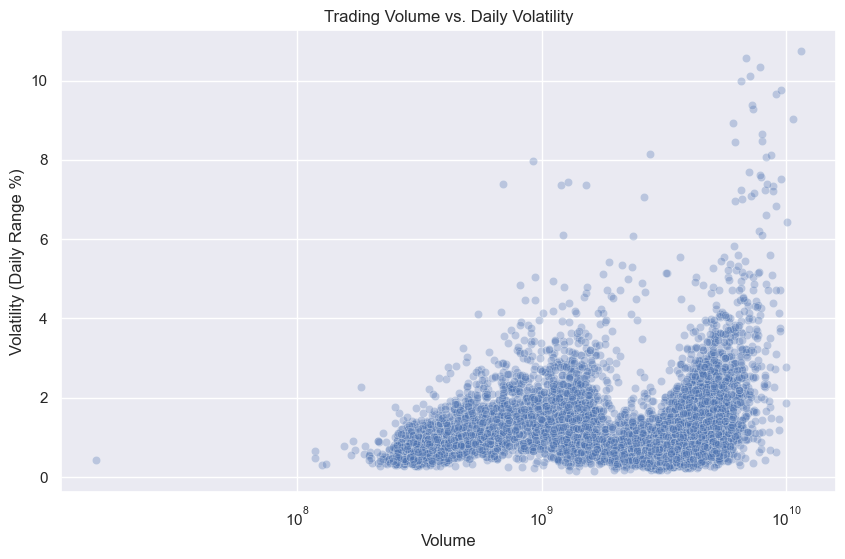

In [22]:
# Define volatility as the daily range percentage
data['Volatility'] = (data['High'] - data['Low']) / data['Close'] * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['Volume'], y=data['Volatility'], alpha=0.3)
plt.title("Trading Volume vs. Daily Volatility")
plt.xlabel("Volume")
plt.ylabel("Volatility (Daily Range %)")
plt.xscale('log') # Log scale helps visualize volume spikes better
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16196\3561307020.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=['red', 'green'])


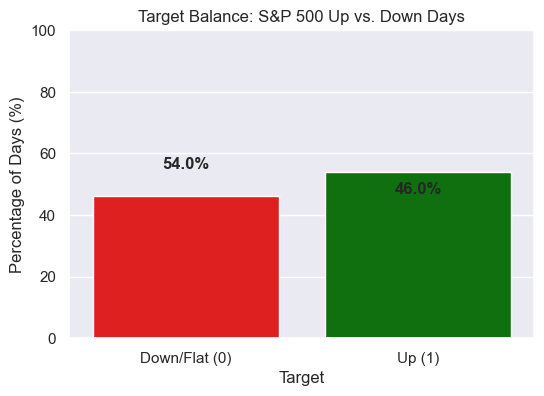

In [23]:
counts = data["Target"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index, y=counts.values, palette=['red', 'green'])
plt.title("Target Balance: S&P 500 Up vs. Down Days")
plt.ylabel("Percentage of Days (%)")
plt.xticks([0, 1], ['Down/Flat (0)', 'Up (1)'])

# Add percentage labels on top of bars
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
    
plt.ylim(0, 100)
plt.show()